# Practical Work 4 - Genetic Algorithm (PW4_GROUP8)

## Step 1 - Environment preparation

In [33]:
%pip install numpy pandas matplotlib seaborn

In [34]:

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from typing import List
from abc import ABC, abstractmethod


### Load the data

In [35]:

# Load data
file_path = 'montly_return.xlsx'
df = pd.read_excel(file_path)
asset_names = df.iloc[:, 0].values
returns_matrix = df.iloc[:, 1:].astype(float).values.T  # We transpose the dataset so the assets are as the headers
n_assets = returns_matrix.shape[1]


# Parameters
Rf = 0.003757

## Step 2 - Implementation

### Normalization method (Simplex projection)

In [36]:
def simplex_projection(v):
    n = len(v)
    u = np.sort(v)[::-1]  # Descending sort
    cssv = np.cumsum(u) - 1 # Cummulative sum
    rho = np.where(u + (1 - cssv) / (np.arange(n) + 1) > 0)[0][-1]
    theta = cssv[rho] / (rho + 1.0)       # Calculate the threshold
    w = np.maximum(v - theta, 0)  # Get maximum between weight - threshold and 0
    return w

### Initialize chromosome and fitness function

In [37]:
class Individual:
    def __init__(self, n_assets):
        self.n_assets = n_assets
        self.genes = simplex_projection(np.random.rand(n_assets)) # Initialize the portfolio weights
        self.fitness = 0.0

    def compute_fitness(self, returns_matrix, Rf):    # Calculate sharpe ratio (fitness value)
        mean_returns = np.mean(returns_matrix, axis=0)
        cov_matrix = np.cov(returns_matrix, rowvar=False)
        portfolio_return = np.dot(self.genes, mean_returns)
        portfolio_volatility = np.sqrt(np.dot(self.genes.T, np.dot(cov_matrix, self.genes)))
        self.fitness = (portfolio_return - Rf) / portfolio_volatility if portfolio_volatility != 0 else -np.inf

    def get_fitness(self):
        return self.fitness

    def set_genes(self, genes):
        self.genes = simplex_projection(genes)

    def get_genes(self):
        return self.genes


### Genetic Algorithm process (Parameters, Operators,...)

In [38]:
class GeneticAlgorithm:
    def __init__(self, n, epochs, Pc, Pm, nres, nsam, n_assets, elites_fraction):
        self.n = n
        self.epochs = epochs
        self.Pc = Pc
        self.Pm = Pm
        self.nres = nres
        self.nsam = nsam
        self.n_assets = n_assets
        self.elites_fraction = elites_fraction
        self.population = []
        self.best_fitness_per_epoch = []
        self.best_n_per_epoch = []
        self.best_percentage_per_epoch = []

    def init_population(self):    # Initialize the population
        self.population = [Individual(self.n_assets) for _ in range(self.n)]

    def compute_fitness(self, returns_matrix, Rf):   # Calculate fitness value
        for individual in self.population:
            individual.compute_fitness(returns_matrix, Rf)

    def selection(self, population, fitness, size):   # Selection operator
        min_fitness = min(fitness)
        shifted_fitness = [f - min_fitness + 1e-6 for f in fitness]
        total_shifted_fitness = sum(shifted_fitness)
        weights = np.array(shifted_fitness) / total_shifted_fitness if total_shifted_fitness > 0 else np.ones(len(population)) / len(population)
        selected_indices = np.random.choice(len(population), size=size, p=weights, replace=True)
        return [population[i] for i in selected_indices]

    def crossover(self, parent1, parent2):    # Crossover operator (roulette wheel method)
        point = np.random.randint(1, self.n_assets)
        child1_genes = np.concatenate([parent1.get_genes()[:point], parent2.get_genes()[point:]])
        child2_genes = np.concatenate([parent2.get_genes()[:point], parent1.get_genes()[point:]])
        child1, child2 = Individual(self.n_assets), Individual(self.n_assets)
        child1.set_genes(child1_genes)
        child2.set_genes(child2_genes)
        return child1, child2

    def mutate(self, individual):   #  Mutation operation
        genes = individual.get_genes()
        for i in range(len(genes)):
            if np.random.rand() < self.Pm:
                genes[i] += (np.random.rand() - 0.5) * 0.1
        individual.set_genes(genes)

    def evolve(self, returns_matrix, Rf):   # Evolution process
        self.init_population()
        for epoch in range(self.epochs):
            self.compute_fitness(returns_matrix, Rf)
            fitness = [ind.get_fitness() for ind in self.population]

            best_fitness = max(fitness)
            best_count = fitness.count(best_fitness)
            best_percentage = best_count / self.n * 100

            self.best_fitness_per_epoch.append(best_fitness)
            self.best_n_per_epoch.append(best_count)
            self.best_percentage_per_epoch.append(best_percentage)

            if epoch % self.nres == 0:
                print(f"Epoch: {epoch}, BESTf: {best_fitness:.4f}, BESTn: {best_count}, BEST%: {best_percentage:.2f}%")

            if epoch % self.nsam == 0:
                sample = random.sample(self.population, int(0.2 * self.n))
                print("Sample of population:")
                for ind in sample:
                    print(f"{ind.get_genes()}, fitness: {ind.get_fitness():.4f}")

            elites_size = int(self.elites_fraction * self.n)
            elites = sorted(zip(self.population, fitness), key=lambda x: x[1], reverse=True)[:elites_size]
            elites = [ind for ind, fit in elites]

            parents = self.selection(self.population, fitness, self.n - elites_size)
            new_population = elites.copy()

            for i in range(0, len(parents), 2):
                if i + 1 < len(parents) and random.random() < self.Pc:
                    child1, child2 = self.crossover(parents[i], parents[i + 1])
                    self.mutate(child1)
                    self.mutate(child2)
                    new_population.extend([child1, child2])
                else:
                    new_population.append(parents[i])

            self.population = new_population[:self.n]

        return self.best_fitness_per_epoch, self.best_n_per_epoch, self.best_percentage_per_epoch

## Step 3 - Execution

In [39]:
# Parameters
n = 1000
epochs = 1000
Pc = 0.8
Pm = 0.1
nres = 20
nsam = 150

# Elitism percentages to evaluate
elitism_percentages = [0.05, 0.1, 0.2, 0.3, 0.4]

# Run the genetic algorithm for each elitism percentage
results = {}

for elitism_percentage in elitism_percentages:
    print(f"\nRunning genetic algorithm with elitism percentage: {elitism_percentage}")
    ga = GeneticAlgorithm(n, epochs, Pc, Pm, nres, nsam, n_assets, elites_fraction=elitism_percentage)
    best_fitness_per_epoch, best_n_per_epoch, best_percentage_per_epoch = ga.evolve(returns_matrix, Rf)
    results[elitism_percentage] = {
        'best_fitness': best_fitness_per_epoch,
        'best_n': best_n_per_epoch,
        'best_percentage': best_percentage_per_epoch
    }

Se han truncado las últimas 5000 líneas del flujo de salida.
[0.28302523 0.10737888 0.0474246  0.         0.         0.12257036
 0.         0.         0.         0.         0.         0.
 0.19400298 0.11256949 0.         0.04155452 0.         0.18413903
 0.         0.        ], fitness: -0.7410
[0.         0.16714979 0.         0.         0.         0.
 0.3007879  0.         0.09256785 0.         0.07056064 0.
 0.1145942  0.         0.10983661 0.         0.         0.
 0.         0.28194697], fitness: -0.9023
[0.         0.         0.         0.         0.         0.35602006
 0.         0.30277667 0.25466616 0.         0.         0.
 0.         0.         0.         0.02958962 0.04173602 0.19310202
 0.         0.        ], fitness: -0.4586
[0.         0.21289025 0.01398648 0.12502514 0.04932435 0.
 0.17462313 0.         0.05480315 0.         0.22819117 0.
 0.         0.         0.         0.07795564 0.         0.
 0.         0.09234366], fitness: -1.2424
[0.02062616 0.         0.      

## Step 4 - Evaluation & Visualization

In [63]:
for elitism_value, data in results.items():
    best_f = max(data['best_fitness'])
    best_f_gen = data['best_fitness'].index(best_f)
    best_n = max(data['best_n'])
    best_n_gen = data['best_n'].index(best_n)
    best_percent = max(data['best_percentage'])
    best_percent_gen = data['best_percentage'].index(best_percent)

    print(f"Elitism {elitism_value:.2f}:")
    print(f"  Mejor BESTf (Fitness): {best_f:.4f}")
    print(f"  Mejor BESTn (Individuals): {best_n}")
    print(f"  Mejor BEST% (Percentage): {best_percent:.2f}")
    print("-" * 40)

Elitism 0.05:
  Mejor BESTf (Fitness): 0.4510
  Mejor BESTn (Individuals): 72
  Mejor BEST% (Percentage): 7.20
----------------------------------------
Elitism 0.10:
  Mejor BESTf (Fitness): 0.4680
  Mejor BESTn (Individuals): 131
  Mejor BEST% (Percentage): 13.10
----------------------------------------
Elitism 0.20:
  Mejor BESTf (Fitness): 0.4634
  Mejor BESTn (Individuals): 241
  Mejor BEST% (Percentage): 24.10
----------------------------------------
Elitism 0.30:
  Mejor BESTf (Fitness): 0.4665
  Mejor BESTn (Individuals): 350
  Mejor BEST% (Percentage): 35.00
----------------------------------------
Elitism 0.40:
  Mejor BESTf (Fitness): 0.4659
  Mejor BESTn (Individuals): 453
  Mejor BEST% (Percentage): 45.30
----------------------------------------


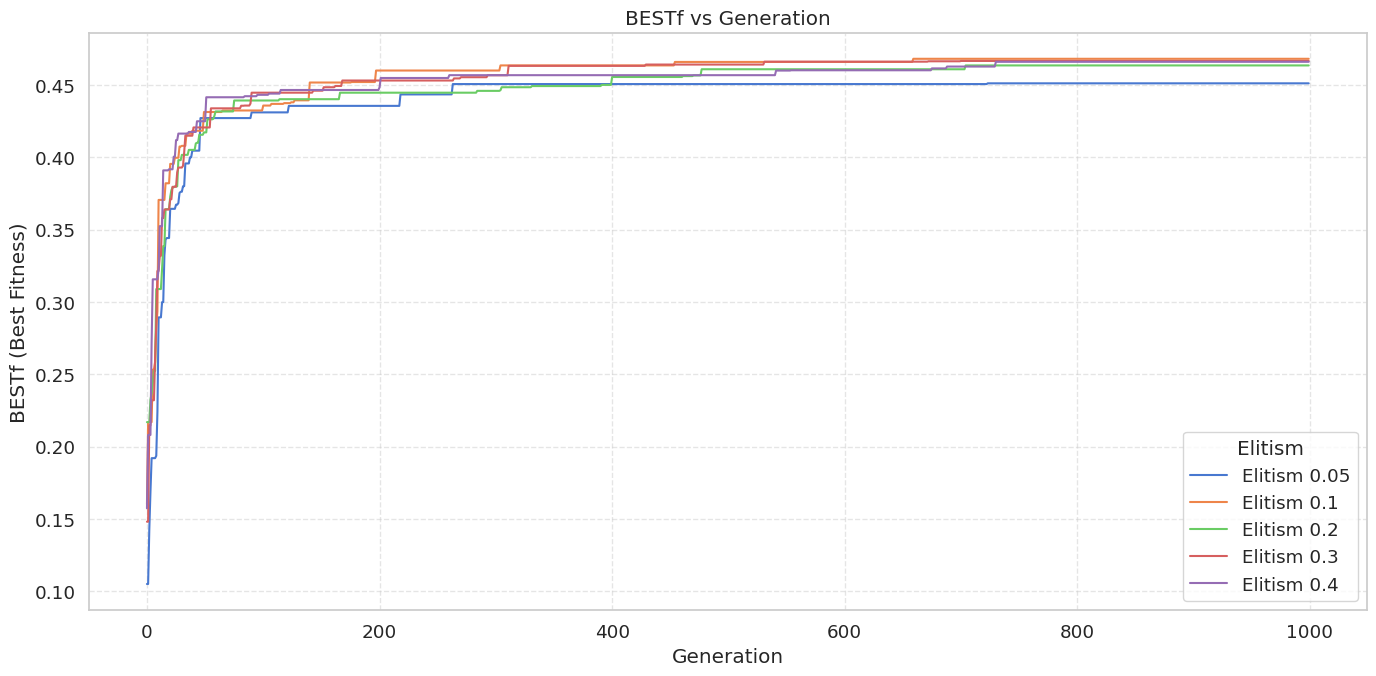

In [50]:
plt.figure(figsize=(14, 7))

for elitism_value, data in results.items():
    best_f_per_epoch = data['best_fitness']
    plt.plot(range(len(best_f_per_epoch)), best_f_per_epoch, label=f'Elitism {elitism_value}')

plt.title('BESTf vs Generation')
plt.xlabel('Generation')
plt.ylabel('BESTf (Best Fitness)')
plt.legend(title='Elitism')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

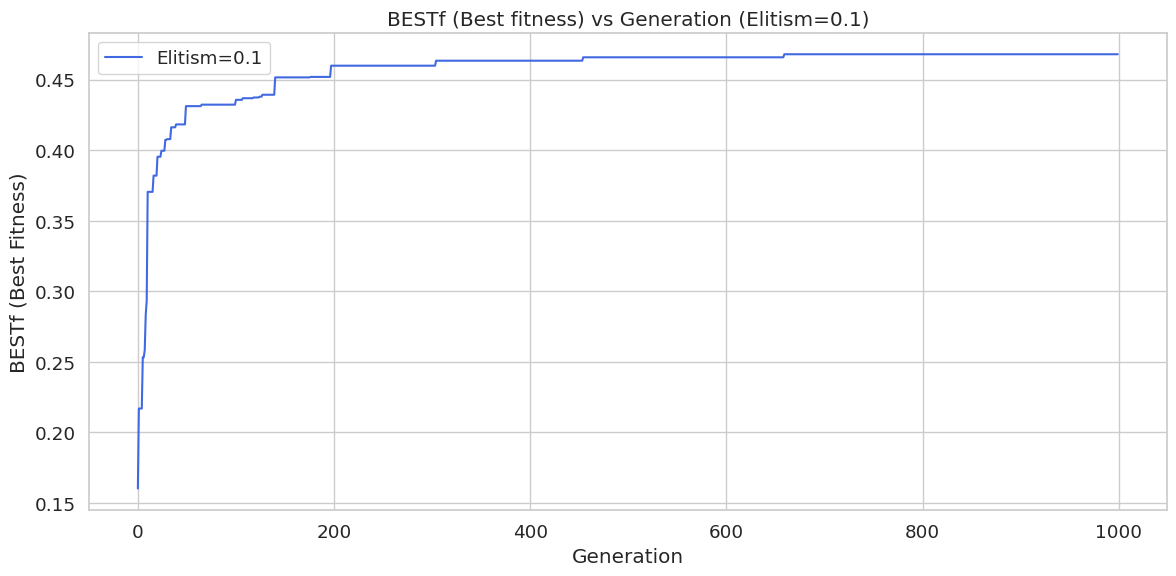

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set(style="whitegrid", palette="muted", font_scale=1.2)

# Data
elitism_value = 0.1
best_fitness = results[elitism_value]['best_fitness']

# Plot
plt.figure(figsize=(12, 6))
plt.plot(best_fitness, label=f'Elitism={elitism_value}', color='royalblue')
plt.title(f"BESTf (Best fitness) vs Generation (Elitism={elitism_value})")
plt.xlabel("Generation")
plt.ylabel("BESTf (Best Fitness)")
plt.legend()
plt.tight_layout()
plt.show()


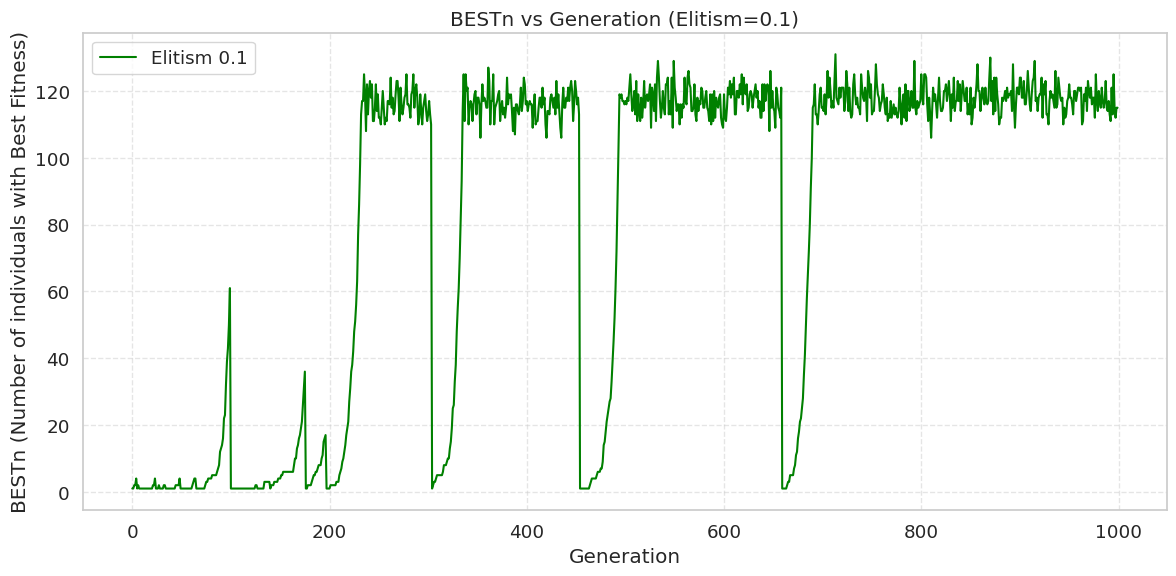

In [60]:
import matplotlib.pyplot as plt

elitism_value = 0.1
best_n_per_epoch = results[elitism_value]['best_n']

plt.figure(figsize=(12, 6))
plt.plot(range(len(best_n_per_epoch)), best_n_per_epoch, label=f'Elitism {elitism_value}', color='green')
plt.title(f'BESTn vs Generation (Elitism={elitism_value})')
plt.xlabel('Generation')
plt.ylabel('BESTn (Number of individuals with Best Fitness)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

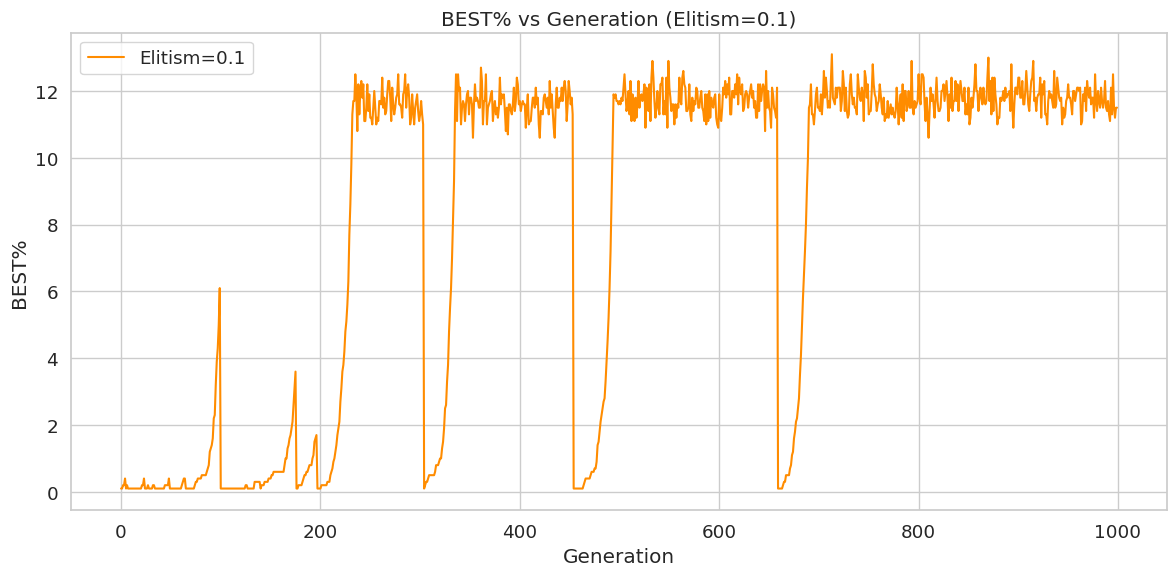

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set(style="whitegrid", palette="muted", font_scale=1.2)

# Data
elitism_value = 0.1
best_percentage = results[elitism_value]['best_percentage']

# Plot
plt.figure(figsize=(12, 6))
plt.plot(best_percentage, label=f'Elitism={elitism_value}', color='darkorange')
plt.title(f"BEST% vs Generation (Elitism={elitism_value})")
plt.xlabel("Generation")
plt.ylabel("BEST%")
plt.legend()
plt.tight_layout()
plt.show()
